In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
print('Impor modul yang digunakan')

Impor modul yang digunakan


In [2]:
df = pd.read_csv ("C:/Users/hp/Documents/Perkuliahan/Semester 4/Data Mining/Pertemuan 10/Final/Data_Tanaman_Padi_Sumatera_version_1.csv")
df.head()

,Provinsi,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
0,Aceh,1993,1329536.0,323589.0,1627.0,82.00,26.06
1,Aceh,1994,1299699.0,329041.0,1521.0,82.12,26.92
2,Aceh,1995,1382905.0,339253.0,1476.0,82.72,26.27
3,Aceh,1996,1419128.0,348223.0,1557.0,83.00,26.08
4,Aceh,1997,1368074.0,337561.0,1339.0,82.46,26.31


In [3]:
df.describe()

,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
count,224.000000,2.240000e+02,224.000000,224.000000,224.000000,224.000000
mean,2006.500000,1.679701e+06,374349.966920,2452.490759,80.948705,26.801964
std,8.095838,1.161387e+06,232751.161987,1031.972625,4.878680,1.197041
min,1993.000000,4.293800e+04,63142.040000,222.500000,54.200000,22.190000
25%,1999.750000,5.488570e+05,146919.500000,1703.525000,78.975000,26.177500
50%,2006.500000,1.667773e+06,373551.500000,2315.700000,82.375000,26.730000
75%,2013.250000,2.436851e+06,514570.250000,3039.700000,84.000000,27.200000
max,2020.000000,4.881089e+06,872737.000000,5522.000000,90.600000,29.850000


In [4]:
print('Rumusan Masalah: \n ')

Rumusan Masalah: 
 


In [5]:
print('Bagaimana menentukan Luas Panen dari dataset ini? ')

Bagaimana menentukan Luas Panen dari dataset ini? 


In [6]:
X = df[['Tahun', 'Produksi', 'Curah hujan', 'Kelembapan', 'Suhu rata-rata'
       ]]
y = df['Luas Panen']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
models = {
    'RandomForest': RandomForestRegressor(random_state=42)
}

In [10]:
for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
        
    print("MAE :", mean_absolute_error(y_test, y_pred))
    print("MSE :", mean_squared_error(y_test, y_pred))
    print("R² Score:", r2_score(y_test, y_pred))


===== RandomForest =====
MAE : 31547.497116176466
MSE : 2680897938.3394074
R² Score: 0.9375423376891375


In [11]:
from sklearn.model_selection import GridSearchCV

In [12]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

In [13]:
models = {
    'Tuned RandomForest': best_rf
}

In [14]:
for name, model in models.items():
    print(f"\n===== {name} =====")
    y_pred = model.predict(X_test)
        
    print("MAE :", mean_absolute_error(y_test, y_pred))
    print("MSE :", mean_squared_error(y_test, y_pred))
    print("R² Score:", r2_score(y_test, y_pred))


===== Tuned RandomForest =====
MAE : 31849.154496327075
MSE : 2463022776.8623238
R² Score: 0.9426182389634282


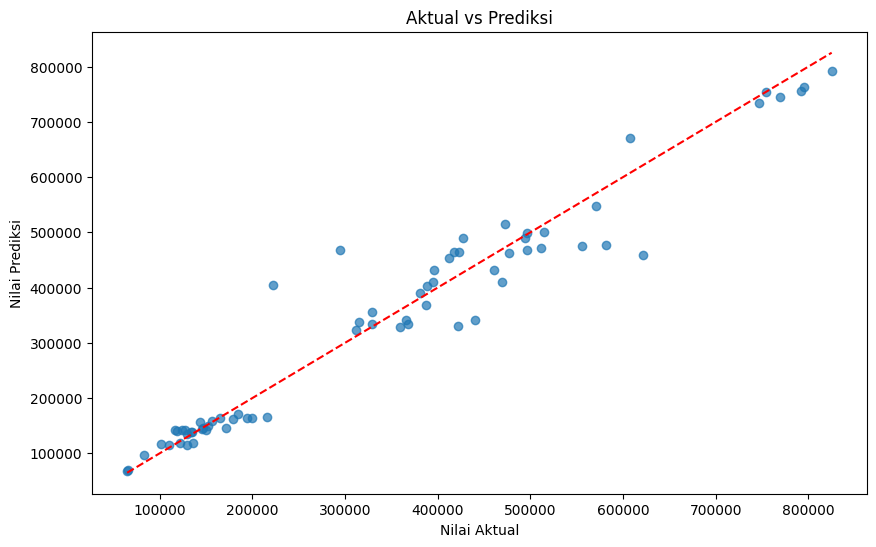

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

y_pred = best_rf.predict(X_test)

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  


plt.title('Aktual vs Prediksi')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')

plt.show()

In [16]:
import joblib

joblib.dump(best_rf, 'model_rf.pkl')

['model_rf.pkl']

In [17]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [20]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Fungsi untuk input data dari pengguna
def get_user_input():
    # Minta input dari pengguna
    Tahun = float(input("Masukkan Tahun: "))
    Produksi = float(input("Masukkan Produksi: "))
    Curah_hujan = float(input("Masukkan Curah Hujan: "))
    Kelembapan = float(input("Masukkan Kelembapan: "))
    Suhu_rata_rata = float(input("Masukkan Suhu rata-rata: "))
    
    # Buat DataFrame dengan data input
    input_data = pd.DataFrame({
        'Tahun': [Tahun],
        'Produksi': [Produksi],
        'Curah hujan': [Curah_hujan],
        'Kelembapan': [Kelembapan],
        'Suhu rata-rata': [Suhu_rata_rata]
    })
    
    return input_data

# Model RandomForest yang sudah dilatih (asumsi)
# Pastikan model sudah dilatih sebelumnya
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)  # Gunakan data latih yang sesuai

# Ambil input pengguna
user_input = get_user_input()

# Prediksi menggunakan model
predicted_revenue = best_rf.predict(user_input)

# Tampilkan hasil prediksi
print("\nHasil Prediksi:")
print(f"Prediksi Luas Panen: {predicted_revenue[0]:,.2f}")


Masukkan Tahun:  2030
Masukkan Produksi:  3000
Masukkan Curah Hujan:  30
Masukkan Kelembapan:  20
Masukkan Suhu rata-rata:  21



Hasil Prediksi:
Prediksi Luas Panen: 66,569.20


In [21]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Fungsi untuk input data dari pengguna
def get_user_input():
    # Minta input dari pengguna
    Tahun = float(input("Masukkan Tahun: "))
    Produksi = float(input("Masukkan Produksi: "))
    Curah_hujan = float(input("Masukkan Curah Hujan: "))
    Kelembapan = float(input("Masukkan Kelembapan: "))
    Suhu_rata_rata = float(input("Masukkan Suhu rata-rata: "))
    
    # Buat DataFrame dengan data input
    input_data = pd.DataFrame({
        'Tahun': [Tahun],
        'Produksi': [Produksi],
        'Curah hujan': [Curah_hujan],
        'Kelembapan': [Kelembapan],
        'Suhu rata-rata': [Suhu_rata_rata]
    })
    
    return input_data

# Model RandomForest yang sudah dilatih (asumsi)
# Pastikan model sudah dilatih sebelumnya
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)  # Gunakan data latih yang sesuai

# Ambil input pengguna
user_input = get_user_input()

# Prediksi menggunakan model
predicted_revenue = best_rf.predict(user_input)

# Tampilkan hasil prediksi
print("\nHasil Prediksi:")
print(f"Prediksi Revenue: {predicted_revenue[0]:,.2f}")


Masukkan Tahun:  3020
Masukkan Produksi:  3000
Masukkan Curah Hujan:  39
Masukkan Kelembapan:  90
Masukkan Suhu rata-rata:  30



Hasil Prediksi:
Prediksi Revenue: 66,404.98


In [23]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Fungsi untuk input data dari pengguna
def get_user_input():
    # Minta input dari pengguna
    Tahun = float(input("Masukkan Tahun: "))
    Produksi = float(input("Masukkan Produksi: "))
    Curah_hujan = float(input("Masukkan Curah Hujan: "))
    Kelembapan = float(input("Masukkan Kelembapan: "))
    Suhu_rata_rata = float(input("Masukkan Suhu rata-rata: "))
    
    # Buat DataFrame dengan data input
    input_data = pd.DataFrame({
        'Tahun': [Tahun],
        'Produksi': [Produksi],
        'Curah hujan': [Curah_hujan],
        'Kelembapan': [Kelembapan],
        'Suhu rata-rata': [Suhu_rata_rata]
    })
    
    return input_data

# Model RandomForest yang sudah dilatih (asumsi)
# Pastikan model sudah dilatih sebelumnya
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)  # Gunakan data latih yang sesuai

# Ambil input pengguna
user_input = get_user_input()

# Prediksi menggunakan model
predicted_revenue = best_rf.predict(user_input)

# Tampilkan hasil prediksi
print("\nHasil Prediksi:")
print(f"Prediksi Luas Panen: {predicted_revenue[0]:,.2f}")


Masukkan Tahun:  2020
Masukkan Produksi:  1900390
Masukkan Curah Hujan:  8902
Masukkan Kelembapan:  87
Masukkan Suhu rata-rata:  34



Hasil Prediksi:
Prediksi Luas Panen: 420,476.20
